In [154]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import mplhep as mplhep
from pathlib import Path
from scipy.ndimage import gaussian_filter,gaussian_filter1d
import os,sys
sys.path.append('/sdf/data/lcls/ds/ued_testfac/scratch/python_packages')
from ued_LCLSII_DAQ_utilities import *

In [155]:
sparse_sim_data=np.zeros((20,500))
sparse_sim_bins=np.linspace(0,1,501) * 1000
num_jobs = 20
num_elecs_arr = np.arange(1000,21000,1000)
edep_maps = [[] for i in range(20)]

for i, num_elecs in enumerate(num_elecs_arr):
    for run_num in range(1,num_jobs + 1):
        sim_filename = f"/sdf/home/d/dhruvshr/SULI2026/ePix_Simulation/Examples/PixelSim_ePix_Data_Gen/outputs/sim_{num_elecs}_e-_run_{run_num:03d}.root"
        sim_file = uproot.open(sim_filename)
        sparse_sim_data[i] += sim_file["TotalEdep"].to_numpy()[0]
        edep_maps[i].append(sim_file["EdepMap"].to_numpy()[0])

In [480]:
NOISE_FACTOR = 0.1770
EDEP_SHIFT = -13.13
BASE_NOISE = 10.0

def digitize(edep_MeV):
    edep_MeV_new = edep_MeV + EDEP_SHIFT
    noise = np.random.normal(loc=0.0, scale=1.0, size=edep_MeV_new.shape)
    return edep_MeV_new + (edep_MeV_new * NOISE_FACTOR * noise) # + np.random.normal(0,BASE_NOISE,size=edep_MeV.shape)

In [481]:
digi_edep_maps = [digitize(edep_map) for edep_map in edep_maps[0]]

In [482]:
# Define some trial peak finding parameters
max_electrons = 1000  # Max number of electrons the peakFinder allowed to find
threshold     = 40    # Threshold for peak finding, pixel intensity below this is filtered
min_signal    = 100   # Min intensity to be considered as electron signal

num_droplets = 0
xs = []
ys = []
droplet_edeps = []
droplet_sizes = []

for job_num in range(20):
    digi_edep_map = digi_edep_maps[job_num]
    n, x, y, edep, size = blobCounter(digi_edep_map, threshold, min_signal)
    num_droplets += n
    xs.append(x)
    ys.append(y)
    droplet_edeps += list(edep)
    droplet_sizes += list(size)

In [483]:
def get_hist_mean(hist):
    counts, edges = hist[0], hist[1]
    bin_centers = (edges[:-1] + edges[1:]) / 2
    mean = np.average(bin_centers, weights=counts)
    return mean

def get_exp_data(run, is_sparse):
    if (is_sparse):
        exp_py = np.load('../../../ePix_Analysis/catalog/Intensity_evts_run_'+str(run)+'_sparse.npy')
    else:
        exp_py = np.load('../../../ePix_Analysis/catalog/Intensity_evts_run_'+str(run)+'_dense.npy')
    bins_intn=np.arange(80,1000,5)
    all_counts = []
    for i_mdl in range(4):
        hist_intn, bin_edges = np.histogram(exp_py[:,i_mdl,:].flatten(), bins=bins_intn)
        all_counts.append(hist_intn)
    exp_counts = np.mean(np.array(all_counts), axis=0)
    return exp_counts

In [484]:
exp_126 = get_exp_data(126,True)
exp_126_dense = get_exp_data(126,False)
exp_bins = np.linspace(80,995,184)[:-1]

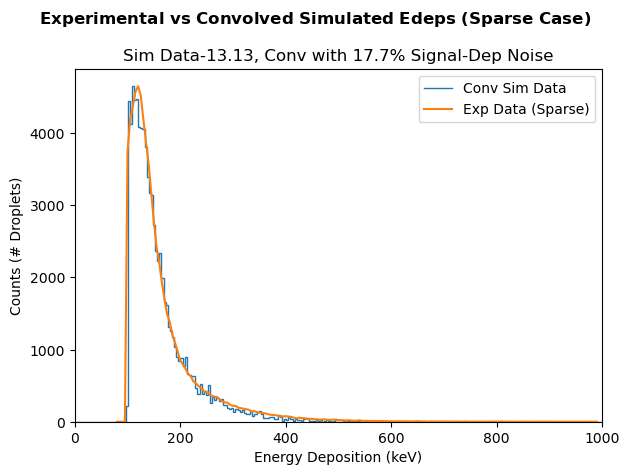

In [485]:
bins = np.linspace(0,2000,500)
counts,_ = np.histogram(droplet_edeps,bins=bins)
match_peak = max(counts)
ratio = max(exp_126) / match_peak
plt.stairs(counts * ratio, bins, label=f"Conv Sim Data")

plt.plot(exp_bins,exp_126, label='Exp Data (Sparse)')

plt.xlabel("Energy Deposition (keV)")
plt.ylabel("Counts (# Droplets)")
plt.suptitle(r"$\bf{Experimental\ vs\ Convolved\ Simulated\ Edeps\ (Sparse\ Case)}$")
plt.title(f"Sim Data{EDEP_SHIFT}, Conv with {NOISE_FACTOR*100}% Signal-Dep Noise"
#          + f" with {BASE_NOISE} keV Base Noise (Signal Indep)"
         )
#if BASE_NOISE != 0:
    
#plt.title(f"Rescaled to Match Peaks, {bin_shift} keV sim shift, {detector_noise} keV Gaussian Conv")
plt.legend()
plt.xlim(0,1000)
plt.tight_layout()

In [486]:
digi_edep_maps_dense = [digitize(edep_map) for edep_map in edep_maps[4]]

In [487]:
# Define some trial peak finding parameters
max_electrons = 1000  # Max number of electrons the peakFinder allowed to find
threshold     = 40    # Threshold for peak finding, pixel intensity below this is filtered
min_signal    = 100   # Min intensity to be considered as electron signal

num_droplets_dense = 0
xs_dense = []
ys_dense = []
droplet_edeps_dense = []
droplet_sizes_dense = []

for job_num in range(20):
    digi_edep_map = digi_edep_maps_dense[job_num]
    n, x, y, edep, size = blobCounter(digi_edep_map, threshold, min_signal)
    num_droplets_dense += n
    xs_dense.append(x)
    ys_dense.append(y)
    droplet_edeps_dense += list(edep)
    droplet_sizes_dense += list(size)

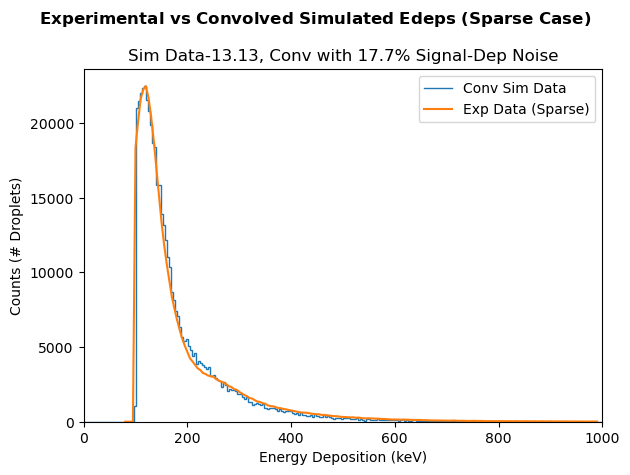

In [488]:
bins = np.linspace(0,2000,500)
counts,_ = np.histogram(droplet_edeps_dense,bins=bins)
match_peak = max(counts)
ratio = max(exp_126_dense) / match_peak
plt.stairs(counts * ratio, bins, label=f"Conv Sim Data")

plt.plot(exp_bins,exp_126_dense, label='Exp Data (Sparse)')

plt.xlabel("Energy Deposition (keV)")
plt.ylabel("Counts (# Droplets)")
plt.suptitle(r"$\bf{Experimental\ vs\ Convolved\ Simulated\ Edeps\ (Sparse\ Case)}$")
plt.title(f"Sim Data{EDEP_SHIFT}, Conv with {NOISE_FACTOR*100}% Signal-Dep Noise"
#          + f" with {BASE_NOISE} keV Base Noise (Signal Indep)"
         )
#if BASE_NOISE != 0:
    
#plt.title(f"Rescaled to Match Peaks, {bin_shift} keV sim shift, {detector_noise} keV Gaussian Conv")
plt.legend()
plt.xlim(0,1000)
plt.tight_layout()

differential_evolution step 1: f(x)= 1648.9567184885564
differential_evolution step 2: f(x)= 1436.0645794052384
differential_evolution step 3: f(x)= 1436.0645794052384
differential_evolution step 4: f(x)= 1416.2909293897405
differential_evolution step 5: f(x)= 1416.2909293897405
differential_evolution step 6: f(x)= 1416.2909293897405
differential_evolution step 7: f(x)= 1415.3998332847855
differential_evolution step 8: f(x)= 1415.3998332847855
differential_evolution step 9: f(x)= 1384.4766619844922
differential_evolution step 10: f(x)= 1384.4766619844922
differential_evolution step 11: f(x)= 1369.3294634158033
differential_evolution step 12: f(x)= 1369.3294634158033
differential_evolution step 13: f(x)= 1369.3294634158033
differential_evolution step 14: f(x)= 1369.3294634158033
differential_evolution step 15: f(x)= 1369.3294634158033
differential_evolution step 16: f(x)= 1369.3294634158033
differential_evolution step 17: f(x)= 1369.3294634158033
differential_evolution step 18: f(x)= 13

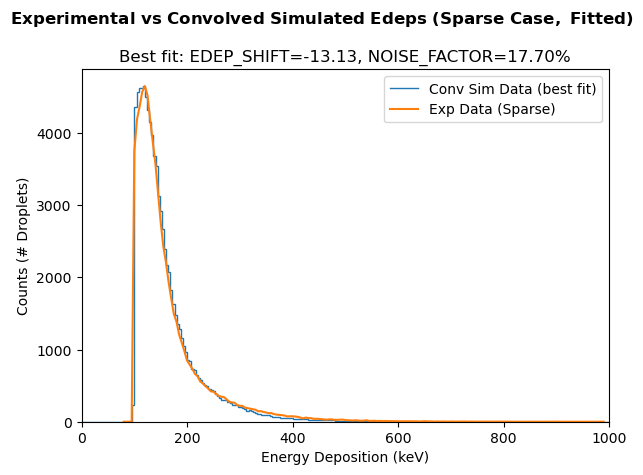

In [453]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import mplhep as mplhep
from pathlib import Path
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from scipy.optimize import differential_evolution
import os, sys
sys.path.append('/sdf/data/lcls/ds/ued_testfac/scratch/python_packages')
from ued_LCLSII_DAQ_utilities import *

# ---------------------------------------------------------------------------
# 1. Load raw sim data once (unchanged from your script)
# ---------------------------------------------------------------------------
sparse_sim_data = np.zeros((20, 500))
sparse_sim_bins = np.linspace(0, 1, 501) * 1000
num_jobs = 20
num_elecs_arr = np.arange(1000, 21000, 1000)
edep_maps = [[] for i in range(20)]

for i, num_elecs in enumerate(num_elecs_arr):
    for run_num in range(1, num_jobs + 1):
        sim_filename = f"/sdf/home/d/dhruvshr/SULI2026/ePix_Simulation/Examples/PixelSim_ePix_Data_Gen/outputs/sim_{num_elecs}_e-_run_{run_num:03d}.root"
        sim_file = uproot.open(sim_filename)
        sparse_sim_data[i] += sim_file["TotalEdep"].to_numpy()[0]
        edep_maps[i].append(sim_file["EdepMap"].to_numpy()[0])

# Peak-finding params (unchanged)
threshold = 40
min_signal = 100

def get_exp_data(run, is_sparse):
    if is_sparse:
        exp_py = np.load('../../../ePix_Analysis/catalog/Intensity_evts_run_' + str(run) + '_sparse.npy')
    else:
        exp_py = np.load('../../../ePix_Analysis/catalog/Intensity_evts_run_' + str(run) + '_dense.npy')
    bins_intn = np.arange(80, 1000, 5)
    all_counts = []
    for i_mdl in range(4):
        hist_intn, bin_edges = np.histogram(exp_py[:, i_mdl, :].flatten(), bins=bins_intn)
        all_counts.append(hist_intn)
    exp_counts = np.mean(np.array(all_counts), axis=0)
    return exp_counts

exp_126 = get_exp_data(126, True)
exp_bins = np.linspace(80, 995, 184)[:-1]

# ---------------------------------------------------------------------------
# 2. Wrap digitize -> blobCounter -> histogram as a function of the two
#    (or three) tunable parameters. base_noise defaults to 0 and is not
#    fit unless you explicitly ask for it (see FIT_BASE_NOISE below).
# ---------------------------------------------------------------------------
FIT_BASE_NOISE = False   # flip to True if you ever want BASE_NOISE in the fit
JOB_INDEX = 0            # which sparsity slice of edep_maps to fit against (sparse case = 0)
N_NOISE_REALIZATIONS = 5 # average over this many random draws per evaluation
HIST_BINS = np.linspace(0, 2000, 500)

def digitize(edep_MeV, edep_shift, noise_factor, base_noise, rng):
    edep_MeV_new = edep_MeV + edep_shift
    noise = rng.normal(loc=0.0, scale=1.0, size=edep_MeV_new.shape)
    out = edep_MeV_new + (edep_MeV_new * noise_factor * noise)
    if base_noise != 0:
        out = out + rng.normal(0, base_noise, size=edep_MeV.shape)
    return out

def simulate_droplet_edeps(edep_shift, noise_factor, base_noise, seed):
    """Run digitize + blob finding once for a given seed. Returns list of droplet edeps."""
    rng = np.random.default_rng(seed)
    droplet_edeps = []
    for job_num in range(20):
        digi_map = digitize(edep_maps[JOB_INDEX][job_num], edep_shift, noise_factor, base_noise, rng)
        n, x, y, edep, size = blobCounter(digi_map, threshold, min_signal)
        droplet_edeps += list(edep)
    return droplet_edeps

def scaled_sim_hist(edep_shift, noise_factor, base_noise, exp_counts, n_realizations=N_NOISE_REALIZATIONS, base_seed=0):
    """Average the histogram over several noise realizations, then peak-match
    scale it to the experimental data, exactly like your original ratio logic."""
    counts_sum = np.zeros(len(HIST_BINS) - 1)
    for k in range(n_realizations):
        droplet_edeps = simulate_droplet_edeps(edep_shift, noise_factor, base_noise, seed=base_seed + k)
        counts, _ = np.histogram(droplet_edeps, bins=HIST_BINS)
        counts_sum += counts
    counts_avg = counts_sum / n_realizations
    match_peak = counts_avg.max()
    if match_peak == 0:
        return counts_avg  # degenerate, will just score badly
    ratio = exp_counts.max() / match_peak
    return counts_avg * ratio

def hist_to_exp_grid(counts, bins, exp_bins):
    """Interpolate the sim histogram (defined on `bins` centers) onto the
    experimental bin centers so the two can be compared point-for-point."""
    bin_centers = (bins[:-1] + bins[1:]) / 2
    return np.interp(exp_bins, bin_centers, counts)

# ---------------------------------------------------------------------------
# 3. Objective function: chi-square between sim and exp histograms
#    (using exp counts + 1 as the variance proxy to avoid div-by-zero and
#    to downweight the low-count tails, similar to a Poisson chi-square)
# ---------------------------------------------------------------------------
def objective(params, exp_counts, exp_bins, base_seed=0):
    if FIT_BASE_NOISE:
        edep_shift, noise_factor, base_noise = params
    else:
        edep_shift, noise_factor = params
        base_noise = 0.0

    sim_counts = scaled_sim_hist(edep_shift, noise_factor, base_noise, exp_counts, base_seed=base_seed)
    sim_on_exp_grid = hist_to_exp_grid(sim_counts, HIST_BINS, exp_bins)

    # only score where there's meaningful experimental signal
    mask = exp_counts > 0
    chi2 = np.sum((sim_on_exp_grid[mask] - exp_counts[mask]) ** 2 / (exp_counts[mask] + 1))
    return chi2

# ---------------------------------------------------------------------------
# 4. Run the fit
# ---------------------------------------------------------------------------
if FIT_BASE_NOISE:
    bounds = [(-40, 5), (0.01, 0.6), (0.0, 30.0)]   # edep_shift, noise_factor, base_noise
else:
    bounds = [(-40, 5), (0.01, 0.6)]                # edep_shift, noise_factor

# IMPORTANT: base_seed is fixed here so the objective function is
# deterministic for a given parameter set. If you let the seed vary between
# calls, differential_evolution will chase noise instead of converging.
result = differential_evolution(
    objective,
    bounds,
    args=(exp_126, exp_bins, 0),
    maxiter=60,
    popsize=15,
    tol=1e-3,
    seed=42,          # controls the optimizer's own search, not the physics noise
    workers=-1,        # parallelize across cores
    updating='deferred',
    disp=True,
)

print("Best-fit parameters:")
if FIT_BASE_NOISE:
    best_shift, best_noise, best_base = result.x
    print(f"  EDEP_SHIFT  = {best_shift:.3f}")
    print(f"  NOISE_FACTOR = {best_noise:.4f}")
    print(f"  BASE_NOISE  = {best_base:.3f}")
else:
    best_shift, best_noise = result.x
    best_base = 0.0
    print(f"  EDEP_SHIFT  = {best_shift:.3f}")
    print(f"  NOISE_FACTOR = {best_noise:.4f}")
print(f"  chi2 = {result.fun:.2f}")

# ---------------------------------------------------------------------------
# 5. Plot best fit against experimental data (higher-stats realization count
#    for a clean-looking final plot)
# ---------------------------------------------------------------------------
final_sim_counts = scaled_sim_hist(best_shift, best_noise, best_base, exp_126, n_realizations=20, base_seed=1000)

plt.stairs(final_sim_counts, HIST_BINS, label="Conv Sim Data (best fit)")
plt.plot(exp_bins, exp_126, label='Exp Data (Sparse)')
plt.xlabel("Energy Deposition (keV)")
plt.ylabel("Counts (# Droplets)")
plt.suptitle(r"$\bf{Experimental\ vs\ Convolved\ Simulated\ Edeps\ (Sparse\ Case,\ Fitted)}$")
plt.title(f"Best fit: EDEP_SHIFT={best_shift:.2f}, NOISE_FACTOR={best_noise*100:.2f}%"
          + (f", BASE_NOISE={best_base:.2f}" if FIT_BASE_NOISE else ""))
plt.legend()
plt.xlim(0, 1000)
plt.tight_layout()
plt.savefig("best_fit_sparse.png", dpi=150)
plt.show()